# Per-Unit Circuit Solution

**System:** Generator G → Transformer T₁ → Transmission Line → Transformer T₂ → Resistive Load C

**Base quantities:** $S_{base} = 10\,\text{MVA}$, $V_{base,1} = 13.2\,\text{kV}$

**Method:** Exact analytical solution

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def cpx(z, fmt='.6f'):
    r, i = z.real, z.imag
    sign = '+' if i >= 0 else '-'
    return f'{r:{fmt}} {sign} j{abs(i):{fmt}}'

def polar(z):
    return f'|{abs(z):.6f}|  ang {np.degrees(np.angle(z)):.4f} deg'

print('Libraries loaded.')

Libraries loaded.


## 1. Base Quantities

The base voltage propagates through each transformer rated turns ratio:

$$V_{base,2} = 13.2 \times \frac{132}{13.2} = 132\,\text{kV}$$

$$V_{base,4} = 132 \times \frac{69}{138} = 66\,\text{kV}$$

$$Z_{base} = V_{base}^2 / S_{base}$$

In [2]:
S_base = 10e6
Vb1 = 13.2e3
Vb2 = Vb1 * (132/13.2)
Vb3 = Vb2
Vb4 = Vb2 * (69/138)
Zb1 = Vb1**2 / S_base
Zb2 = Vb2**2 / S_base
Zb4 = Vb4**2 / S_base

print(f'{'Zone':<10} {'V_base (kV)':>14} {'Z_base (Ohm)':>14}')
print('-'*42)
for label, Vb, Zb in [('Bus 1', Vb1/1e3, Zb1),
                       ('Bus 2-3', Vb2/1e3, Zb2),
                       ('Bus 4',  Vb4/1e3, Zb4)]:
    print(f'{label:<10} {Vb:>14.3f} {Zb:>14.4f}')

Zone          V_base (kV)   Z_base (Ohm)
------------------------------------------
Bus 1              13.200        17.4240
Bus 2-3           132.000      1742.4000
Bus 4              66.000       435.6000


## 2. Generator G — Per-Unit Parameters

Convert synchronous reactance from machine base to system base:

$$X_s^{sys} = X_s^{rated} \times \frac{S_{base}}{S_{n,G}} \times \left(\frac{V_{n,G}}{V_{base,1}}\right)^2$$

Since $V_{n,G} = V_{base,1}$ the voltage ratio is unity.

In [3]:
Sn_G = 5e6
Vn_G = 13.2e3
Xs_pu_rated = 0.20
Xs_G = Xs_pu_rated * (S_base/Sn_G) * (Vn_G/Vb1)**2
V1 = complex(1.0, 0.0)

print(f'Generator Xs = j{Xs_G:.6f} pu  (system base)')
print(f'Terminal V1  = {cpx(V1)} pu')

Generator Xs = j0.400000 pu  (system base)
Terminal V1  = 1.000000 + j0.000000 pu


## 3. Transformer T1 — T-Equivalent Parameters

**Rated:** 5 MVA, 13.2/132 kV.  Since $V_{n,HV} = V_{base,2} = 132\,\text{kV}$, the impedance conversion factor is $k_Z = S_{base}/S_{n,T1} = 2$.

Series (SC test): $R_{cc} = P_{cc}/S_{n,T1}$,  $X_{cc} = \sqrt{v_{cc}^2 - R_{cc}^2}$  — split equally into two half-windings.

Shunt (OC test): $G_m = P_0/S_{n,T1}$,  $B_m = \sqrt{i_0^2 - G_m^2}$  — placed at the **midpoint** of the T-model.

Admittance conversion factor: $k_Y = S_{n,T1}/S_{base} = 0.5$.

In [4]:
Sn_T1 = 5e6
Vn_T1_HV = 132e3
kT1  = (S_base/Sn_T1) * (Vn_T1_HV/Vb2)**2
kYT1 = (Sn_T1/S_base) * (Vb2/Vn_T1_HV)**2

# Series branch
Vcc_T1 = 0.10;  Pcc_T1 = 50e3
Rcc_r  = Pcc_T1/Sn_T1
Xcc_r  = np.sqrt(Vcc_T1**2 - Rcc_r**2)
Rcc_T1 = Rcc_r * kT1;  Xcc_T1 = Xcc_r * kT1
R_T1a = R_T1b = Rcc_T1/2;  X_T1a = X_T1b = Xcc_T1/2
Z_T1a = complex(R_T1a, X_T1a)
Z_T1b = complex(R_T1b, X_T1b)

# Shunt branch (midpoint)
P0_T1 = 15e3;  I0_T1 = 0.02
Gm_r  = P0_T1/Sn_T1
Bm_r  = np.sqrt(I0_T1**2 - Gm_r**2)
Gm_T1 = Gm_r * kYT1;  Bm_T1 = Bm_r * kYT1
Ym_T1 = complex(Gm_T1, -Bm_T1)

print('Transformer T1  (system base)')
print(f'  Z_T1a (LV half) = {cpx(Z_T1a)} pu')
print(f'  Z_T1b (HV half) = {cpx(Z_T1b)} pu')
print(f'  Ym_T1 (midpnt)  = {cpx(Ym_T1)} pu')

Transformer T1  (system base)
  Z_T1a (LV half) = 0.010000 + j0.099499 pu
  Z_T1b (HV half) = 0.010000 + j0.099499 pu
  Ym_T1 (midpnt)  = 0.001500 - j0.009887 pu


## 4. Transformer T2 — T-Equivalent Parameters

**Rated:** 10 MVA, 138/69 kV.  System base at HV: 132 kV.

The turns ratio 138/69 = 2 equals the base ratio 132/66 = 2, so the **off-nominal tap ratio is exactly 1.0** — no ideal transformer element is needed.

However the HV rated voltage differs from the base, so:

$$k_Z = \left(\frac{138}{132}\right)^2 = 1.0930, \qquad k_Y = \left(\frac{132}{138}\right)^2 = 0.9149$$

In [5]:
Sn_T2 = 10e6
Vn_T2_HV = 138e3
kT2  = (S_base/Sn_T2) * (Vn_T2_HV/Vb2)**2
kYT2 = (Sn_T2/S_base) * (Vb2/Vn_T2_HV)**2
print(f'T2  k_Z = {kT2:.6f}   k_Y = {kYT2:.6f}')

# Series branch
Vcc_T2 = 0.08;  Pcc_T2 = 80e3
Rcc_r2 = Pcc_T2/Sn_T2
Xcc_r2 = np.sqrt(Vcc_T2**2 - Rcc_r2**2)
Rcc_T2 = Rcc_r2 * kT2;  Xcc_T2 = Xcc_r2 * kT2
R_T2a = R_T2b = Rcc_T2/2;  X_T2a = X_T2b = Xcc_T2/2
Z_T2a = complex(R_T2a, X_T2a)
Z_T2b = complex(R_T2b, X_T2b)

# Shunt branch (midpoint)
P0_T2 = 20e3;  I0_T2 = 0.015
Gm_r2 = P0_T2/Sn_T2
Bm_r2 = np.sqrt(I0_T2**2 - Gm_r2**2)
Gm_T2 = Gm_r2 * kYT2;  Bm_T2 = Bm_r2 * kYT2
Ym_T2 = complex(Gm_T2, -Bm_T2)

print('Transformer T2  (system base)')
print(f'  Z_T2a (HV half) = {cpx(Z_T2a)} pu')
print(f'  Z_T2b (LV half) = {cpx(Z_T2b)} pu')
print(f'  Ym_T2 (midpnt)  = {cpx(Ym_T2)} pu')

T2  k_Z = 1.092975   k_Y = 0.914934
Transformer T2  (system base)
  Z_T2a (HV half) = 0.004372 + j0.043500 pu
  Z_T2b (LV half) = 0.004372 + j0.043500 pu
  Ym_T2 (midpnt)  = 0.001830 - j0.013601 pu


## 5. Transmission Line — Pi-Equivalent Parameters

$$Z_L^{pu} = Z_L[\Omega]/Z_{base,2}, \qquad (Y_L/2)^{pu} = (Y_L/2)[S] \times Z_{base,2}$$

In [6]:
ZL_ohm = complex(10, 100)
YL2_S  = complex(0, 1.5e-4)
ZL  = ZL_ohm / Zb2
YL2 = YL2_S  * Zb2

print('Transmission line  (system base)')
print(f'  Z_L   = {cpx(ZL)} pu')
print(f'  Y_L/2 = {cpx(YL2)} pu  (each pi-end)')

Transmission line  (system base)
  Z_L   = 0.005739 + j0.057392 pu
  Y_L/2 = 0.000000 + j0.261360 pu  (each pi-end)


## 6. Load C — Per-Unit Parameter

$$Z_C^{pu} = Z_C[\Omega] / Z_{base,4}$$

In [7]:
ZC_ohm = 1100.0
ZC = ZC_ohm / Zb4
print(f'Load  Z_C = {ZC:.6f} pu   (Z_base4 = {Zb4:.4f} Ohm)')

Load  Z_C = 2.525253 pu   (Z_base4 = 435.6000 Ohm)


## 7. Per-Unit Parameter Summary

In [8]:
print('='*62)
print('  NETWORK PARAMETERS  (S_base=10 MVA)')
print('='*62)
print(f'  Generator  Xs      = j{Xs_G:.6f}          pu')
print(f'  T1  Z_T1a (LV)    = {cpx(Z_T1a)} pu')
print(f'  T1  Ym_T1 (mid)   = {cpx(Ym_T1)} pu')
print(f'  T1  Z_T1b (HV)    = {cpx(Z_T1b)} pu')
print(f'  Line Z_L           = {cpx(ZL)} pu')
print(f'  Line Y_L/2 (bus2) = {cpx(YL2)} pu')
print(f'  Line Y_L/2 (bus3) = {cpx(YL2)} pu')
print(f'  T2  Z_T2a (HV)    = {cpx(Z_T2a)} pu')
print(f'  T2  Ym_T2 (mid)   = {cpx(Ym_T2)} pu')
print(f'  T2  Z_T2b (LV)    = {cpx(Z_T2b)} pu')
print(f'  Load Z_C           = {ZC:.6f}+j0.000000 pu')

  NETWORK PARAMETERS  (S_base=10 MVA)
  Generator  Xs      = j0.400000          pu
  T1  Z_T1a (LV)    = 0.010000 + j0.099499 pu
  T1  Ym_T1 (mid)   = 0.001500 - j0.009887 pu
  T1  Z_T1b (HV)    = 0.010000 + j0.099499 pu
  Line Z_L           = 0.005739 + j0.057392 pu
  Line Y_L/2 (bus2) = 0.000000 + j0.261360 pu
  Line Y_L/2 (bus3) = 0.000000 + j0.261360 pu
  T2  Z_T2a (HV)    = 0.004372 + j0.043500 pu
  T2  Ym_T2 (mid)   = 0.001830 - j0.013601 pu
  T2  Z_T2b (LV)    = 0.004372 + j0.043500 pu
  Load Z_C           = 2.525253+j0.000000 pu


## 8. Per-Unit Circuit Diagram

Magnetising branches sit at the **midpoints** of each transformer T-model, exactly as in the hand-drawn schematic.

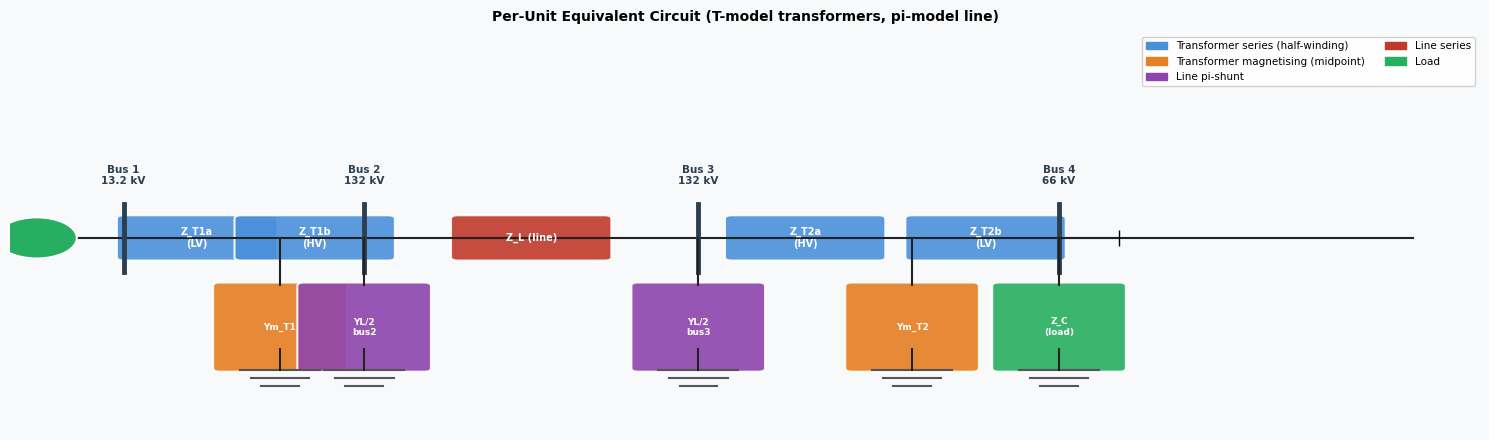

In [9]:
fig, ax = plt.subplots(figsize=(15, 4.5))
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-2.8, 3.0)
ax.axis('off')
fig.patch.set_facecolor('#f8f9fa')

def wire(x0,y0,x1,y1,col='#222',lw=1.5): ax.plot([x0,x1],[y0,y1],color=col,lw=lw)
def sbox(cx,cy,lbl,col): 
    ax.add_patch(mpatches.FancyBboxPatch((cx-.55,cy-.28),1.1,.56,
        boxstyle='round,pad=0.05',fc=col,ec='white',lw=1.5,alpha=.9))
    ax.text(cx,cy,lbl,ha='center',va='center',fontsize=7,color='white',fontweight='bold')
def ybox(cx,cy,lbl,col):
    ax.add_patch(mpatches.FancyBboxPatch((cx-.45,cy-.6),.9,1.2,
        boxstyle='round,pad=0.05',fc=col,ec='white',lw=1.5,alpha=.9))
    ax.text(cx,cy,lbl,ha='center',va='center',fontsize=6.5,color='white',fontweight='bold')
def bus(x,lbl):
    ax.plot([x,x],[-.5,.5],color='#2c3e50',lw=3.5)
    ax.text(x,.75,lbl,ha='center',va='bottom',fontsize=7.5,fontweight='bold',color='#2c3e50')
def gnd(x,y):
    for i,w in enumerate([.3,.22,.14]): ax.plot([x-w,x+w],[y-i*.12,y-i*.12],color='#555',lw=1.5)
    wire(x,y+.3,x,y)

YM=0.0; YS=-1.3
wire(-0.3,YM,10.0,YM)
# source
ax.add_patch(plt.Circle((-0.3,YM),.3,fc='#27ae60',ec='white',lw=1.5,zorder=5))
ax.text(-0.3,YM,'V1\n1<0',ha='center',va='center',fontsize=6,color='white',fontweight='bold')
# buses
bus(0.35,'Bus 1\n13.2 kV'); bus(2.15,'Bus 2\n132 kV')
bus(4.65,'Bus 3\n132 kV'); bus(7.35,'Bus 4\n66 kV')
# T1
sbox(0.9,YM,'Z_T1a\n(LV)','#4A90D9')
wire(1.52,YM,1.52,YS+.62); ybox(1.52,YS,'Ym_T1','#E67E22'); gnd(1.52,YS-.62)
sbox(1.78,YM,'Z_T1b\n(HV)','#4A90D9')
# line
wire(2.15,YM,2.15,YS+.62); ybox(2.15,YS,'YL/2\nbus2','#8e44ad'); gnd(2.15,YS-.62)
sbox(3.4,YM,'Z_L (line)','#c0392b')
wire(4.65,YM,4.65,YS+.62); ybox(4.65,YS,'YL/2\nbus3','#8e44ad'); gnd(4.65,YS-.62)
# T2
sbox(5.45,YM,'Z_T2a\n(HV)','#4A90D9')
wire(6.25,YM,6.25,YS+.62); ybox(6.25,YS,'Ym_T2','#E67E22'); gnd(6.25,YS-.62)
sbox(6.8,YM,'Z_T2b\n(LV)','#4A90D9')
# load
wire(7.35,YM,7.35,YS+.62); ybox(7.35,YS,'Z_C\n(load)','#27ae60'); gnd(7.35,YS-.62)
wire(7.35,YM,7.8,YM); ax.plot(7.8,YM,'k|',ms=12)

patches=[
    mpatches.Patch(color='#4A90D9',label='Transformer series (half-winding)'),
    mpatches.Patch(color='#E67E22',label='Transformer magnetising (midpoint)'),
    mpatches.Patch(color='#8e44ad',label='Line pi-shunt'),
    mpatches.Patch(color='#c0392b',label='Line series'),
    mpatches.Patch(color='#27ae60',label='Load'),
]
ax.legend(handles=patches,loc='upper right',fontsize=7.5,framealpha=.9,ncol=2)
ax.set_title('Per-Unit Equivalent Circuit (T-model transformers, pi-model line)',
             fontsize=10,fontweight='bold',pad=8)
plt.tight_layout()
plt.savefig('tmp/circuit.png',dpi=150,bbox_inches='tight')
plt.show()

## 9. Backward Impedance Sweep — Bus 4 to Bus 1

Working from right to left, at each shunt node:

$$Z_{left} = Z_{series} + \frac{1}{Y_{shunt} + 1/Z_{right}}$$

This is exact — no approximation or iteration is needed for a linear circuit.

In [10]:
print('='*70)
print('BACKWARD IMPEDANCE SWEEP')
print('='*70)

Z = ZC
print(f'Step 0  Z_C (load)                = {cpx(Z)} pu')

Z = Z + Z_T2b
print(f'Step 1  + Z_T2b                   = {cpx(Z)} pu')

Z = 1/(Ym_T2 + 1/Z)
print(f'Step 2  || Ym_T2 (mid T2)         = {cpx(Z)} pu')

Z = Z + Z_T2a
print(f'Step 3  + Z_T2a                   = {cpx(Z)} pu')

Z = 1/(YL2 + 1/Z)
print(f'Step 4  || Y_L/2 (bus 3)          = {cpx(Z)} pu')

Z = Z + ZL
print(f'Step 5  + Z_L (line)              = {cpx(Z)} pu')

Z = 1/(YL2 + 1/Z)
print(f'Step 6  || Y_L/2 (bus 2)          = {cpx(Z)} pu')

Z = Z + Z_T1b
print(f'Step 7  + Z_T1b                   = {cpx(Z)} pu')

Z = 1/(Ym_T1 + 1/Z)
print(f'Step 8  || Ym_T1 (mid T1)         = {cpx(Z)} pu')

Z = Z + Z_T1a
print(f'Step 9  + Z_T1a                   = {cpx(Z)} pu')

Z_total = Z
print(f'\nZ_total seen from Bus 1 = {cpx(Z_total)} pu')
print(f'  {polar(Z_total)}')

BACKWARD IMPEDANCE SWEEP
Step 0  Z_C (load)                = 2.525253 + j0.000000 pu
Step 1  + Z_T2b                   = 2.529624 + j0.043500 pu
Step 2  || Ym_T2 (mid T2)         = 2.512080 + j0.129058 pu
Step 3  + Z_T2a                   = 2.516452 + j0.172558 pu
Step 4  || Y_L/2 (bus 3)          = 1.871798 - j1.108517 pu
Step 5  + Z_L (line)              = 1.877537 - j1.051125 pu
Step 6  || Y_L/2 (bus 2)          = 1.006336 - j1.211988 pu
Step 7  + Z_T1b                   = 1.016336 - j1.112489 pu
Step 8  || Ym_T1 (mid T1)         = 1.039198 - j1.110837 pu
Step 9  + Z_T1a                   = 1.049198 - j1.011338 pu

Z_total seen from Bus 1 = 1.049198 - j1.011338 pu
  |1.457265|  ang -43.9474 deg


## 10. Generator Current and Power

$$\bar{I}_1 = \bar{V}_1 / Z_{total}, \qquad \bar{S}_{gen} = \bar{V}_1\,\bar{I}_1^*$$

In [11]:
I1 = V1 / Z_total
S_gen = V1 * np.conj(I1)
P_gen_pu = S_gen.real;  Q_gen_pu = S_gen.imag
sb = S_base/1e6
P_gen_MW   = P_gen_pu * sb
Q_gen_MVAR = Q_gen_pu * sb

print('Generator  (Bus 1)')
print(f'  I1        = {cpx(I1)} pu    {polar(I1)}')
print(f'  S_gen(pu) = {cpx(S_gen)} pu')
print(f'  P_gen     = {P_gen_MW:.4f} MW')
print(f'  Q_gen     = {Q_gen_MVAR:.4f} MVAR  (negative => absorbed => leading PF)')
print(f'  |S_gen|   = {abs(S_gen)*sb:.4f} MVA')
print(f'  cos(phi)  = {abs(P_gen_pu/abs(S_gen)):.6f}  leading')

Generator  (Bus 1)
  I1        = 0.494061 + j0.476233 pu    |0.686217|  ang 43.9474 deg
  S_gen(pu) = 0.494061 - j0.476233 pu
  P_gen     = 4.9406 MW
  Q_gen     = -4.7623 MVAR  (negative => absorbed => leading PF)
  |S_gen|   = 6.8622 MVA
  cos(phi)  = 0.719977  leading


## 11. Forward Voltage/Current Sweep — Bus 1 to Bus 4

Propagate voltages and currents forward:

$$V_{next} = V_{prev} - Z_{series}\,I_{series}, \qquad I_{next} = I_{prev} - V_{node}\,Y_{shunt}$$

In [12]:
print('='*70)
print('FORWARD SWEEP')
print('='*70)

# Bus 1
I_s = I1
print(f'\nBus 1   V = {cpx(V1)}  |V|={abs(V1):.6f} pu  ang={np.degrees(np.angle(V1)):.4f} deg')
print(f'        I = {cpx(I_s)} pu')

# Through Z_T1a -> midpoint T1
V_mT1 = V1 - Z_T1a * I_s
I_Ym1 = V_mT1 * Ym_T1
I_s   = I_s - I_Ym1
print(f'\nMid-T1  V = {cpx(V_mT1)}  |V|={abs(V_mT1):.6f} pu')
print(f'        I_Ym1 = {cpx(I_Ym1)} pu')

# Through Z_T1b -> Bus 2
V_bus2 = V_mT1 - Z_T1b * I_s
I_YL2b2 = V_bus2 * YL2
I_s = I_s - I_YL2b2
print(f'\nBus 2   V = {cpx(V_bus2)}  |V|={abs(V_bus2):.6f} pu  ang={np.degrees(np.angle(V_bus2)):.4f} deg')
print(f'        Actual: {abs(V_bus2)*Vb2/1e3:.4f} kV')
print(f'        I_YL2 = {cpx(I_YL2b2)} pu')

# Through Z_L -> Bus 3
V_bus3 = V_bus2 - ZL * I_s
I_YL2b3 = V_bus3 * YL2
I_s = I_s - I_YL2b3
print(f'\nBus 3   V = {cpx(V_bus3)}  |V|={abs(V_bus3):.6f} pu  ang={np.degrees(np.angle(V_bus3)):.4f} deg')
print(f'        Actual: {abs(V_bus3)*Vb2/1e3:.4f} kV')
print(f'        I_YL2 = {cpx(I_YL2b3)} pu')

# Through Z_T2a -> midpoint T2
V_mT2 = V_bus3 - Z_T2a * I_s
I_Ym2 = V_mT2 * Ym_T2
I_s   = I_s - I_Ym2
print(f'\nMid-T2  V = {cpx(V_mT2)}  |V|={abs(V_mT2):.6f} pu')
print(f'        I_Ym2 = {cpx(I_Ym2)} pu')

# Through Z_T2b -> Bus 4
V_bus4 = V_mT2 - Z_T2b * I_s
I_load = V_bus4 / ZC
print(f'\nBus 4   V = {cpx(V_bus4)}  |V|={abs(V_bus4):.6f} pu  ang={np.degrees(np.angle(V_bus4)):.4f} deg')
print(f'        Actual: {abs(V_bus4)*Vb4/1e3:.4f} kV')
print(f'        I_load = {cpx(I_load)} pu')
print(f'\nVerification |I_series - I_load| = {abs(I_s - I_load):.3e} pu')

FORWARD SWEEP

Bus 1   V = 1.000000 + j0.000000  |V|=1.000000 pu  ang=0.0000 deg
        I = 0.494061 + j0.476233 pu

Mid-T1  V = 1.042444 - j0.053921  |V|=1.043838 pu
        I_Ym1 = 0.001031 - j0.010387 pu

Bus 2   V = 1.085932 - j0.107843  |V|=1.091274 pu  ang=-5.6714 deg
        Actual: 144.0481 kV
        I_YL2 = 0.028186 + j0.283819 pu

Bus 3   V = 1.094903 - j0.135685  |V|=1.103278 pu  ang=-7.0643 deg
        Actual: 145.6328 kV
        I_YL2 = 0.035463 + j0.286164 pu

Mid-T2  V = 1.089400 - j0.153999  |V|=1.100230 pu
        I_Ym2 = -0.000101 - j0.015099 pu

Bus 4   V = 1.084553 - j0.172383  |V|=1.098167 pu  ang=-9.0313 deg
        Actual: 72.4790 kV
        I_load = 0.429483 - j0.068264 pu

Verification |I_series - I_load| = 1.943e-16 pu


## 12. Active and Reactive Power at Every Component

Copper losses: $P_{Cu} = |I|^2 R \times S_{base}$  
Core losses: $P_{Fe} = |V_{mid}|^2 G_m \times S_{base}$  
Capacitive Q (generated): $Q_{cap} = -|V|^2 B_{cap} \times S_{base}$ (negative = supplied)

In [13]:
# Re-collect branch currents from forward sweep
I_s0 = I1
I_s1 = I_s0 - V_mT1 * Ym_T1
I_s2 = I_s1 - V_bus2 * YL2
I_s3 = I_s2 - V_bus3 * YL2
I_s4 = I_s3 - V_mT2  * Ym_T2

P_gen    = (V1 * np.conj(I_s0)).real * sb
Q_gen    = (V1 * np.conj(I_s0)).imag * sb

P_T1cu   = (abs(I_s0)**2 * R_T1a + abs(I_s1)**2 * R_T1b) * sb
Q_T1cu   = (abs(I_s0)**2 * X_T1a + abs(I_s1)**2 * X_T1b) * sb
P_T1fe   = abs(V_mT1)**2 * Gm_T1 * sb
Q_T1fe   = abs(V_mT1)**2 * Bm_T1 * sb

P_line   = abs(I_s2)**2 * ZL.real * sb
Q_line   = abs(I_s2)**2 * ZL.imag * sb
Q_YL2b2  = -abs(V_bus2)**2 * YL2.imag * sb
Q_YL2b3  = -abs(V_bus3)**2 * YL2.imag * sb

P_T2cu   = (abs(I_s3)**2 * R_T2a + abs(I_s4)**2 * R_T2b) * sb
Q_T2cu   = (abs(I_s3)**2 * X_T2a + abs(I_s4)**2 * X_T2b) * sb
P_T2fe   = abs(V_mT2)**2 * Gm_T2 * sb
Q_T2fe   = abs(V_mT2)**2 * Bm_T2 * sb

P_load   = abs(V_bus4)**2 / ZC * sb
Q_load   = 0.0

fmt = '{:<30} {:>+10.4f} {:>+12.4f}'
print(f'{'Component':<30} {'P (MW)':>10} {'Q (MVAR)':>12}')
print('-'*55)
print(fmt.format('Generator (injected)',  P_gen, Q_gen))
print('-'*55)
print(fmt.format('T1 copper',   -P_T1cu, -Q_T1cu))
print(fmt.format('T1 core',     -P_T1fe, -Q_T1fe))
print(fmt.format('Line series', -P_line, -Q_line))
print(fmt.format('Line cap bus2',  0.0,   Q_YL2b2))
print(fmt.format('Line cap bus3',  0.0,   Q_YL2b3))
print(fmt.format('T2 copper',   -P_T2cu, -Q_T2cu))
print(fmt.format('T2 core',     -P_T2fe, -Q_T2fe))
print(fmt.format('Load C',      -P_load, -Q_load))
print('-'*55)
P_res = P_gen - P_T1cu - P_T1fe - P_line - P_T2cu - P_T2fe - P_load
Q_res = Q_gen - Q_T1cu - Q_T1fe - Q_line - Q_YL2b2 - Q_YL2b3 - Q_T2cu - Q_T2fe
print(fmt.format('RESIDUAL (=> 0)', P_res, Q_res))
total_losses = P_T1cu + P_T1fe + P_line + P_T2cu + P_T2fe
print(f'\nTotal losses = {total_losses:.4f} MW')
print(f'Efficiency   = {P_load/P_gen*100:.2f} %')

Component                          P (MW)     Q (MVAR)
-------------------------------------------------------
Generator (injected)              +4.9406      -4.7623
-------------------------------------------------------
T1 copper                         -0.0951      -0.9460
T1 core                           -0.0163      -0.1077
Line series                       -0.0148      -0.1476
Line cap bus2                     +0.0000      -3.1125
Line cap bus3                     +0.0000      -3.1813
T2 copper                         -0.0166      -0.1655
T2 core                           -0.0222      -0.1646
Load C                            -4.7756      -0.0000
-------------------------------------------------------
RESIDUAL (=> 0)                   -0.0000      -0.0000

Total losses = 0.1650 MW
Efficiency   = 96.66 %


## 13. Power Balance Visualisation

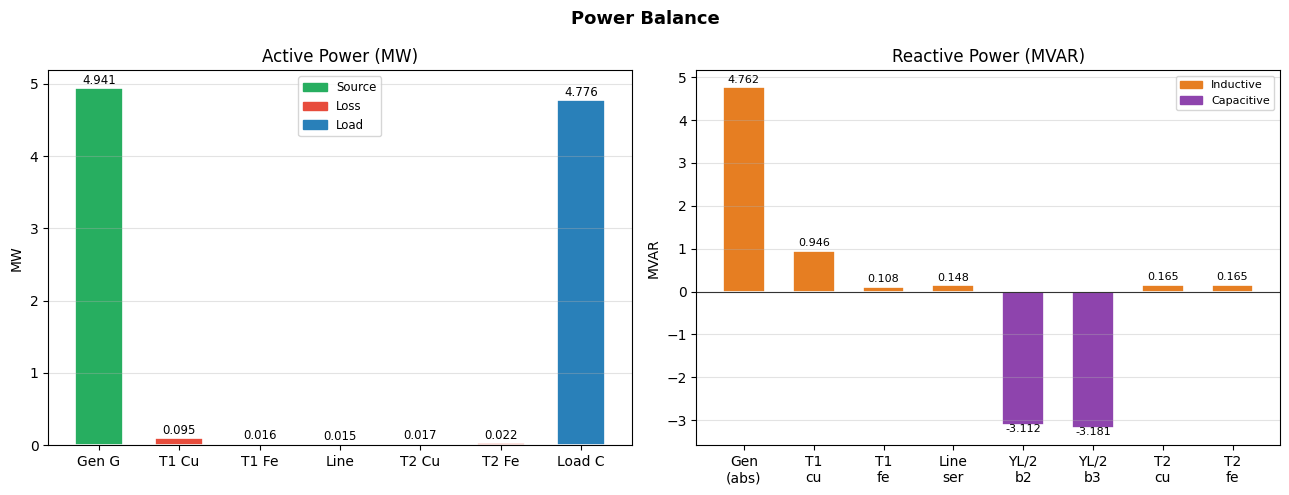

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Power Balance', fontsize=13, fontweight='bold')

# Active power
ax = axes[0]
lbls = ['Gen G','T1 Cu','T1 Fe','Line','T2 Cu','T2 Fe','Load C']
vals = [P_gen, P_T1cu, P_T1fe, P_line, P_T2cu, P_T2fe, P_load]
cols = ['#27ae60','#e74c3c','#e74c3c','#e74c3c','#e74c3c','#e74c3c','#2980b9']
bars = ax.bar(lbls, vals, color=cols, width=0.6, edgecolor='white', lw=1.2)
for b,v in zip(bars,vals):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8.5)
ax.set_ylabel('MW'); ax.set_title('Active Power (MW)')
ax.grid(axis='y', alpha=0.35)
ax.legend(handles=[mpatches.Patch(color='#27ae60',label='Source'),
                   mpatches.Patch(color='#e74c3c',label='Loss'),
                   mpatches.Patch(color='#2980b9',label='Load')], fontsize=8.5)

# Reactive power
ax2 = axes[1]
qlbls = ['Gen\n(abs)','T1\ncu','T1\nfe','Line\nser',
         'YL/2\nb2','YL/2\nb3','T2\ncu','T2\nfe']
qvals = [-Q_gen, Q_T1cu, Q_T1fe, Q_line, Q_YL2b2, Q_YL2b3, Q_T2cu, Q_T2fe]
qcols = ['#8e44ad' if v<0 else '#e67e22' for v in qvals]
ax2.bar(qlbls, qvals, color=qcols, width=0.6, edgecolor='white', lw=1.2)
for i,(v) in enumerate(qvals):
    ax2.text(i, v+(0.06 if v>=0 else -0.2), f'{v:.3f}',
             ha='center', va='bottom', fontsize=8)
ax2.axhline(0, color='#333', lw=0.8)
ax2.set_ylabel('MVAR'); ax2.set_title('Reactive Power (MVAR)')
ax2.grid(axis='y', alpha=0.35)
ax2.legend(handles=[mpatches.Patch(color='#e67e22',label='Inductive'),
                    mpatches.Patch(color='#8e44ad',label='Capacitive')], fontsize=8)

plt.tight_layout()
plt.savefig('tmp/power_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Voltage Profile

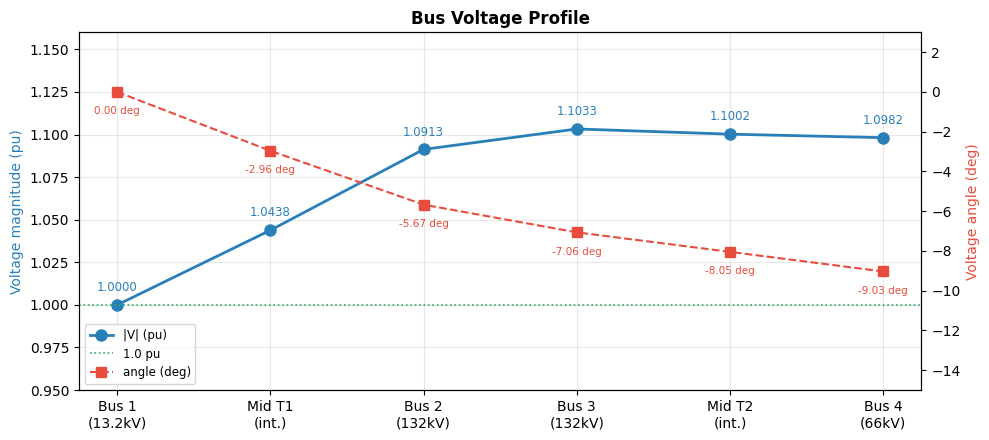

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
nodes = ['Bus 1\n(13.2kV)','Mid T1\n(int.)','Bus 2\n(132kV)',
         'Bus 3\n(132kV)','Mid T2\n(int.)','Bus 4\n(66kV)']
Vs = [V1, V_mT1, V_bus2, V_bus3, V_mT2, V_bus4]
mags   = [abs(v) for v in Vs]
angles = [np.degrees(np.angle(v)) for v in Vs]
ax2b = ax.twinx()
ax.plot(nodes, mags, 'o-', color='#2980b9', lw=2, ms=8, label='|V| (pu)')
ax2b.plot(nodes, angles, 's--', color='#e74c3c', lw=1.5, ms=7, label='angle (deg)')
ax.axhline(1.0, color='#27ae60', ls=':', lw=1.2, label='1.0 pu')
for i,(m,a) in enumerate(zip(mags,angles)):
    ax.annotate(f'{m:.4f}',(i,m),textcoords='offset points',xytext=(0,10),
                ha='center',fontsize=8.5,color='#2980b9')
    ax2b.annotate(f'{a:.2f} deg',(i,a),textcoords='offset points',xytext=(0,-16),
                  ha='center',fontsize=7.5,color='#e74c3c')
ax.set_ylabel('Voltage magnitude (pu)', color='#2980b9')
ax2b.set_ylabel('Voltage angle (deg)', color='#e74c3c')
ax.set_title('Bus Voltage Profile', fontsize=12, fontweight='bold')
ax.set_ylim(0.95, 1.16); ax2b.set_ylim(-15, 3)
l1,lb1=ax.get_legend_handles_labels(); l2,lb2=ax2b.get_legend_handles_labels()
ax.legend(l1+l2,lb1+lb2,fontsize=8.5,loc='lower left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tmp/voltage_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Final Summary

In [16]:
SEP = '='*62
print(SEP)
print('  FINAL RESULTS SUMMARY  (S_base = 10 MVA)')
print(SEP)
print('  Bus voltages:')
for name, V, Vb in [('Bus 1 (gen)', V1, Vb1),
                    ('Bus 2 (HV) ', V_bus2, Vb2),
                    ('Bus 3 (HV) ', V_bus3, Vb2),
                    ('Bus 4 (load)',V_bus4, Vb4)]:
    print(f'    {name:<12} |V|={abs(V):.5f} pu  '
          f'ang={np.degrees(np.angle(V)):+.3f} deg  '
          f'({abs(V)*Vb/1e3:.3f} kV)')
print()
print(f'  Generator:  P = {P_gen:.4f} MW   Q = {Q_gen:.4f} MVAR   |S| = {abs(S_gen)*sb:.4f} MVA')
print(f'  Power factor = {abs(P_gen/abs(S_gen*sb)):.5f}  leading')
print(f'  Load:       P = {P_load:.4f} MW   Q = 0.0000 MVAR')
print(f'  Total losses = {total_losses:.4f} MW')
print(f'  Efficiency   = {P_load/P_gen*100:.2f} %')
print()
print(f'  Balance check:  delta_P = {P_res:+.3e} MW    delta_Q = {Q_res:+.3e} MVAR')
print(SEP)

  FINAL RESULTS SUMMARY  (S_base = 10 MVA)
  Bus voltages:
    Bus 1 (gen)  |V|=1.00000 pu  ang=+0.000 deg  (13.200 kV)
    Bus 2 (HV)   |V|=1.09127 pu  ang=-5.671 deg  (144.048 kV)
    Bus 3 (HV)   |V|=1.10328 pu  ang=-7.064 deg  (145.633 kV)
    Bus 4 (load) |V|=1.09817 pu  ang=-9.031 deg  (72.479 kV)

  Generator:  P = 4.9406 MW   Q = -4.7623 MVAR   |S| = 6.8622 MVA
  Power factor = 0.71998  leading
  Load:       P = 4.7756 MW   Q = 0.0000 MVAR
  Total losses = 0.1650 MW
  Efficiency   = 96.66 %

  Balance check:  delta_P = -8.882e-16 MW    delta_Q = -3.969e-15 MVAR
